In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_ctrl = scarf.DataStore(
    f"{ctrl_path}/data.zarr",
    nthreads=4,
    zarr_mode="r+",
)
ds_stim = scarf.DataStore(
    f"{stim_path}/data.zarr",
    nthreads=4,
    zarr_mode="r+",
)

Downloading bucket files: 40169307 / 40169307 complete

Downloading bytes: 40169307 / 40169307 complete

Downloading bucket files: 46151508 / 46151508 complete

Downloading bytes: 46151508 / 46151508 complete

In [2]:
ds_ctrl.cells.insert(
    "reference_batch",
    np.repeat("control", ds_ctrl.cells.N),
    overwrite=True,
)

In [3]:
artifacts = ds_ctrl.pipeline.run(
    filtering=False,
    cell_cycle_scoring=False,
    highly_variable_features={
        "min_cells": 10,
        "top_n": 2000,
        "min_mean": -3,
        "max_mean": 2,
        "max_var": 6,
    },
    pca={"dims": 25},
    harmony={"batch_columns": ["reference_batch"]},
    neighbors={"k": 17},
    umap=False,
    leiden={},
    paris=False,
    doublet_scoring=False,
    markers=False,
)
reference = ds_ctrl.build_mapping_reference(artifacts["neighbors"])

Loading uncorrected latent dimensions: 1 / 1 complete

Harmonizing batches: 50 / 50 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

In [4]:
reference = ds_ctrl.get_mapping_reference()

In [5]:
query_batches = pd.DataFrame(
    {
        "reference_batch": np.repeat(
            "stimulated",
            len(ds_stim.cells.fetch("ids", key="I")),
        )
    }
)
mapping = ds_stim.run_mapping(
    reference,
    "stim_atlas",
    query_assay="RNA",
    save_k=5,
    query_batches=query_batches,
)

In [6]:
mapped = ds_stim.get_mapping_result(
    "stim_atlas",
    reference=reference,
    query_assay="RNA",
    load_arrays=True,
)
mapped.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'symphony',
 'zeroNormCellCount': 0,
 'queryScaledDispersion': 1.2273312252910447}

In [7]:
transferred = ds_stim.get_target_classes(
    mapped,
    reference_class_group="cluster_labels",
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "atlas_labels",
    transferred.to_numpy(),
    overwrite=True,
)

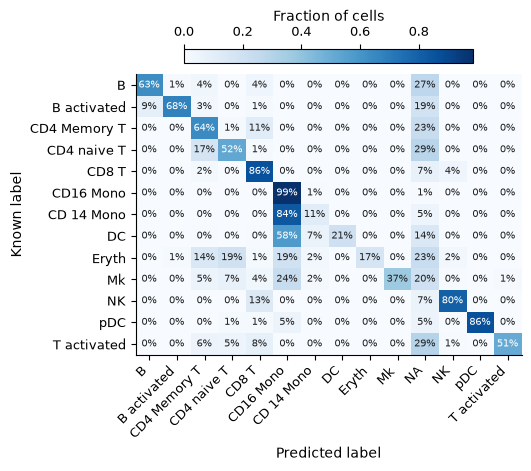

In [8]:
query_labels = np.asarray(ds_stim.cells.fetch("cluster_labels")).astype(str)
ds_stim.plots.mapping_confusion(
    mapped,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    normalize="true",
    threshold_fraction=0.6,
)

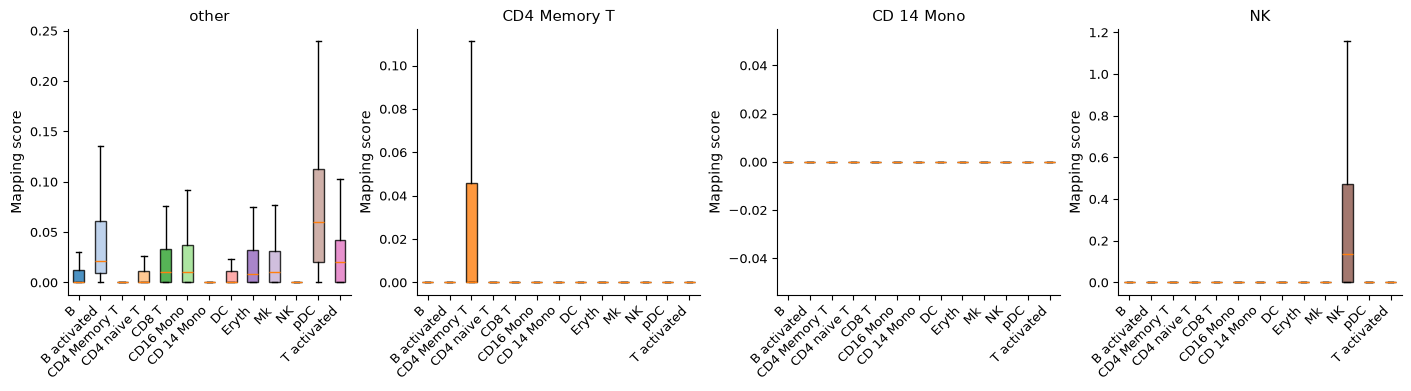

In [9]:
focus_groups = np.array(
    [
        label if label in {"CD4 Memory T", "CD 14 Mono", "NK"} else "other"
        for label in query_labels
    ],
    dtype=object,
)
ds_stim.plots.mapping_score(
    mapped,
    target_groups=focus_groups,
    kind="box",
    reference_class_group="cluster_labels",
    figsize=(14, 3.8),
)

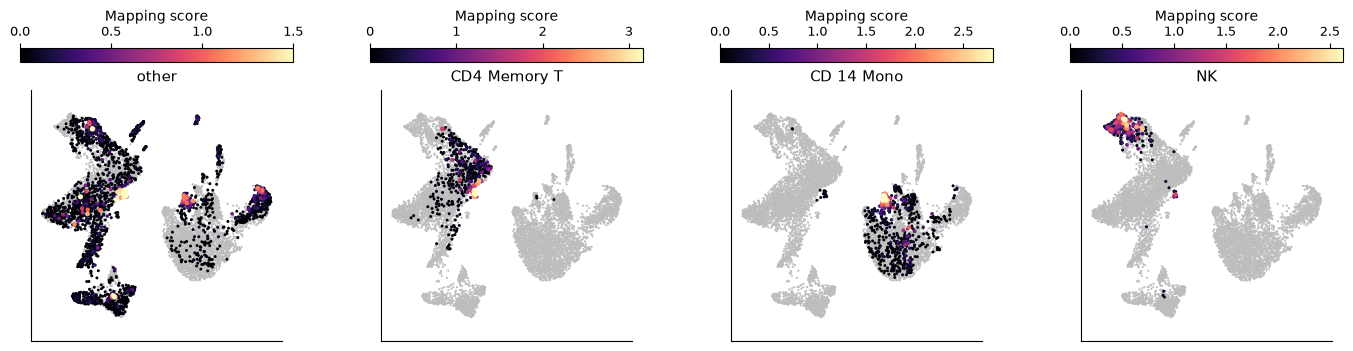

In [10]:
ds_stim.plots.mapping_score(
    mapped,
    layout_key="RNA_UMAP",
    target_groups=focus_groups,
    size_by_score=True,
    figsize=(14, 3.4),
)